In [115]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel

data_path = "/home/dsemchin/COMIND/notebooks/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"
time_col = "time"
df_all = pd.read_csv(data_path)

# one row per subject (final visit)
final_idx = df_all.groupby("subj_id")[time_col].idxmax()
subj_df = df_all.loc[final_idx].copy()

subj_df["NSD_STAGE"] = pd.to_numeric(subj_df["NSD_STAGE"], errors="coerce")
subj_df.loc[subj_df["NSD_STAGE"] == 0, "NSD_STAGE"] = np.nan

cat_levels = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
subj_df["NSD_ordered"] = pd.Categorical(subj_df["NSD_STAGE"], categories=cat_levels, ordered=True)

cols_needed = ["NSD_ordered", "MCATOT", "TD_score", "PIGD_score", "model_split_best"]
model_df = subj_df.dropna(subset=cols_needed).copy()

ord_train = model_df[model_df["model_split_best"] == "train"].copy()
ord_val = model_df[model_df["model_split_best"] == "val"].copy()

ord_train["NSD_ordered"] = ord_train["NSD_ordered"].cat.remove_unused_categories()
ord_val["NSD_ordered"] = ord_val["NSD_ordered"].cat.remove_unused_categories()

# same category order in both splits (use full scale from training fit)
full_cats = ord_train["NSD_ordered"].cat.categories
ord_val["NSD_ordered"] = pd.Categorical(
    ord_val["NSD_ordered"].astype(float), categories=full_cats, ordered=True
)

print("\nRows by model_split_best:")
print(df_all["model_split_best"].value_counts(dropna=False))
print("\nUnique subjects by model_split_best:")
print(df_all.groupby("model_split_best")["subj_id"].nunique())
print("\nPatients with NSD stage (complete cases):")
print("Train n:", len(ord_train), "| Val n:", len(ord_val))
print("Train NSD counts:\n", ord_train["NSD_ordered"].value_counts().sort_index())
print("Val NSD counts:\n", ord_val["NSD_ordered"].value_counts().sort_index())


Rows by model_split_best:
model_split_best
train       513
not_used    235
val         132
Name: count, dtype: int64

Unique subjects by model_split_best:
model_split_best
not_used    231
train       116
val          30
Name: subj_id, dtype: int64

Patients with NSD stage (complete cases):
Train n: 98 | Val n: 25
Train NSD counts:
 NSD_ordered
3.0    67
4.0    28
5.0     2
6.0     1
Name: count, dtype: int64
Val NSD counts:
 NSD_ordered
3.0    17
4.0     6
5.0     2
6.0     0
Name: count, dtype: int64


In [116]:
print(df_all["subtype_best"].value_counts(dropna=True))

subtype_best
0.0    330
1.0    224
2.0     91
Name: count, dtype: int64


In [117]:
class WeightedOrderedModel(OrderedModel):
    def __init__(self, endog, exog, sample_weights=None, distr="logit", **kwargs):
        super().__init__(endog, exog, distr=distr, **kwargs)
        if sample_weights is None:
            sample_weights = np.ones(self.nobs)
        w = np.asarray(sample_weights, dtype=float)
        self.sample_weights = w * (self.nobs / w.sum())

    def loglikeobs(self, params):
        return self.sample_weights * super().loglikeobs(params)

    def score_obs(self, params):
        return self.sample_weights[:, None] * super().score_obs(params)

## Ord regression clinical scores only

                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -84.721
Model:             WeightedOrderedModel   AIC:                             181.4
Method:              Maximum Likelihood   BIC:                             197.0
Date:                  Mon, 27 Apr 2026                                         
Time:                          18:56:52                                         
No. Observations:                    98                                         
Df Residuals:                        92                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT        -0.6448      2.032     -0.317      0.751      -4.628       3.339
TD_score      -0.0814      0.718  

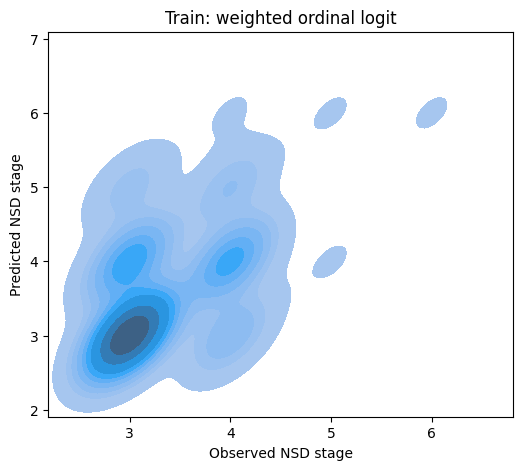

Train accuracy: 0.6429


In [118]:
y_train = ord_train["NSD_ordered"]
X_train = ord_train[["MCATOT", "TD_score", "PIGD_score"]]
w_train = compute_sample_weight(class_weight="balanced", y=y_train)

mod_train = WeightedOrderedModel(y_train, X_train, sample_weights=w_train, distr="logit")
res_train = mod_train.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_train.summary())

pred_probas_train = res_train.model.predict(params=res_train.params, exog=X_train)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(full_cats[pred_idx_train], index=y_train.index).astype(float)
true_cat_train = y_train.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_train, y=pred_cat_train, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Train: weighted ordinal logit")
plt.show()
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")


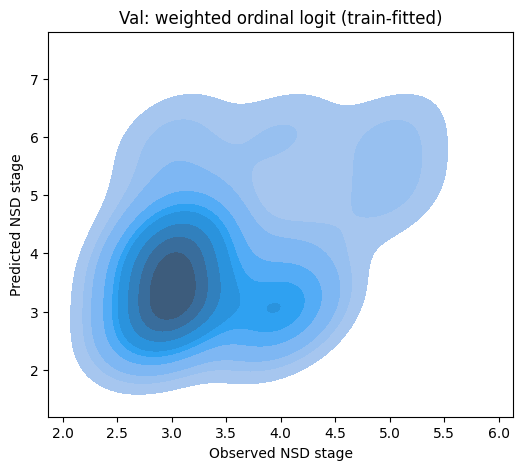

Val accuracy: 0.4000


In [119]:

y_val = ord_val["NSD_ordered"]
X_val = ord_val[["MCATOT", "TD_score", "PIGD_score"]]
pred_probas_val = res_train.model.predict(params=res_train.params, exog=X_val)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(full_cats[pred_idx_val], index=y_val.index).astype(float)
true_cat_val = y_val.astype(float)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("Val: weighted ordinal logit (train-fitted)")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

In [120]:
from sklearn.metrics import f1_score

# train (use your pred_cat_train / true_cat_train)
f1_train = f1_score(
    true_cat_train,
    pred_cat_train,
    average="weighted",
    labels=full_cats.astype(float),  # or list(full_cats); keeps class order stable
    zero_division=0,
)

# val
f1_val = f1_score(
    true_cat_val,
    pred_cat_val,
    average="weighted",
    labels=full_cats.astype(float),
    zero_division=0,
)


print(f1_train)
print(f1_val)

0.6790774160904031
0.44945812807881774


### ord regression with subtype

In [121]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight

SUBTYPE = [0, 1, 2]
clin_cols = ["MCATOT", "TD_score", "PIGD_score"]

sub_train = pd.Series(
    pd.Categorical(ord_train["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_train.index,
)
subtype_dummies = pd.get_dummies(
    sub_train, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
X_train_sub = pd.concat([ord_train[clin_cols], subtype_dummies], axis=1)

w_train = compute_sample_weight(class_weight="balanced", y=ord_train["NSD_ordered"])
mod_sub = WeightedOrderedModel(
    ord_train["NSD_ordered"], X_train_sub, sample_weights=w_train, distr="logit"
)
res_sub = mod_sub.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_sub.summary())

sub_val = pd.Series(
    pd.Categorical(ord_val["subtype_best"].astype(int), categories=SUBTYPE),
    index=ord_val.index,
)
subtype_dummies_val = pd.get_dummies(
    sub_val, prefix="subtype", prefix_sep="_", drop_first=True
).astype(int)
subtype_dummies_val = subtype_dummies_val.reindex(
    columns=subtype_dummies.columns, fill_value=0
)
X_val_sub = pd.concat([ord_val[clin_cols], subtype_dummies_val], axis=1)


                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -80.076
Model:             WeightedOrderedModel   AIC:                             176.2
Method:              Maximum Likelihood   BIC:                             196.8
Date:                  Mon, 27 Apr 2026                                         
Time:                          18:56:53                                         
No. Observations:                    98                                         
Df Residuals:                        90                                         
Df Model:                             5                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT        -0.6517      1.915     -0.340      0.734      -4.404       3.101
TD_score      -0.0732      0.335  

In [122]:
pred_probas_train = res_sub.model.predict(params=res_sub.params, exog=X_train_sub)
pred_idx_train = np.argmax(pred_probas_train, axis=1)
pred_cat_train = pd.Series(
    full_cats[pred_idx_train], index=ord_train["NSD_ordered"].index
).astype(float)
true_cat_train = ord_train["NSD_ordered"].astype(float)
print(f"Train accuracy: {np.mean(pred_cat_train.values == true_cat_train.values):.4f}")

pred_probas_val = res_sub.model.predict(params=res_sub.params, exog=X_val_sub)
pred_idx_val = np.argmax(pred_probas_val, axis=1)
pred_cat_val = pd.Series(
    full_cats[pred_idx_val], index=ord_val["NSD_ordered"].index
).astype(float)
true_cat_val = ord_val["NSD_ordered"].astype(float)
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

Train accuracy: 0.5714
Val accuracy: 0.4000


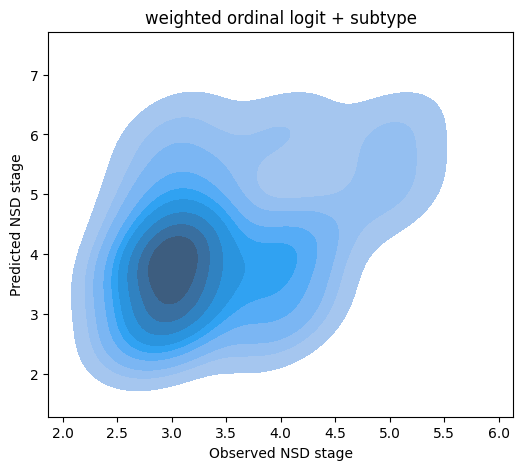

Val accuracy: 0.4000


In [123]:
plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title("weighted ordinal logit + subtype")
plt.show()
print(f"Val accuracy: {np.mean(pred_cat_val.values == true_cat_val.values):.4f}")

In [124]:
from sklearn.metrics import f1_score

# train (use your pred_cat_train / true_cat_train)
f1_train = f1_score(
    true_cat_train,
    pred_cat_train,
    average="weighted",
    labels=full_cats.astype(float),  # or list(full_cats); keeps class order stable
    zero_division=0,
)

# val
f1_val = f1_score(
    true_cat_val,
    pred_cat_val,
    average="weighted",
    labels=full_cats.astype(float),
    zero_division=0,
)


print(f1_train)
print(f1_val)

0.6110544217687075
0.4431058823529412


0.6790774160904031
0.44945812807881774

## New new version

In [125]:
# Soft subtype: use probabilities directly (reference = implicit in omitting subtype_proba_0)
FEATURES_SOFT = [
    "MCATOT", "TD_score", "PIGD_score",
    "subtype_proba_1",
    "subtype_proba_2",
]

for c in FEATURES_SOFT:
    if c not in ord_train.columns:
        raise KeyError(
            f"Missing {c!r}. Point data_path at a CSV that includes subtype_proba_* "
            "on longitudinal rows (so final-visit rows inherit them), or add those columns to subj_df."
        )

soft_train = ord_train.dropna(subset=FEATURES_SOFT + ["NSD_ordered"]).copy()
soft_val = ord_val.dropna(subset=FEATURES_SOFT + ["NSD_ordered"]).copy()

soft_train["NSD_ordered"] = soft_train["NSD_ordered"].cat.remove_unused_categories()
train_cats = soft_train["NSD_ordered"].cat.categories
soft_val["NSD_ordered"] = pd.Categorical(
    soft_val["NSD_ordered"].astype(float),
    categories=train_cats,
    ordered=True,
)

X_train_soft = soft_train[FEATURES_SOFT].astype(float)
X_val_soft = soft_val[FEATURES_SOFT].astype(float)

w_train = compute_sample_weight("balanced", y=soft_train["NSD_ordered"])
mod_soft = WeightedOrderedModel(
    soft_train["NSD_ordered"],
    X_train_soft,
    sample_weights=w_train,
    distr="logit",
)
res_soft = mod_soft.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_soft.summary())

pred_probas = res_soft.model.predict(params=res_soft.params, exog=X_val_soft)
pred_idx = np.argmax(pred_probas, axis=1)
pred_cat = pd.Series(train_cats[pred_idx], index=soft_val["NSD_ordered"].index).astype(float)
true_cat = soft_val["NSD_ordered"].astype(float)
print(f"Soft model — train n: {len(soft_train)} | val n: {len(soft_val)}")
print(f"Val accuracy: {np.mean(pred_cat.values == true_cat.values):.4f}")

                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -83.054
Model:             WeightedOrderedModel   AIC:                             182.1
Method:              Maximum Likelihood   BIC:                             202.8
Date:                  Mon, 27 Apr 2026                                         
Time:                          18:56:54                                         
No. Observations:                    98                                         
Df Residuals:                        90                                         
Df Model:                             5                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
MCATOT             -0.6709      2.312     -0.290      0.772      -5.203       3.861
TD_score           

without subtyping:
- train: 0.6790774160904031
- val: 0.44945812807881774

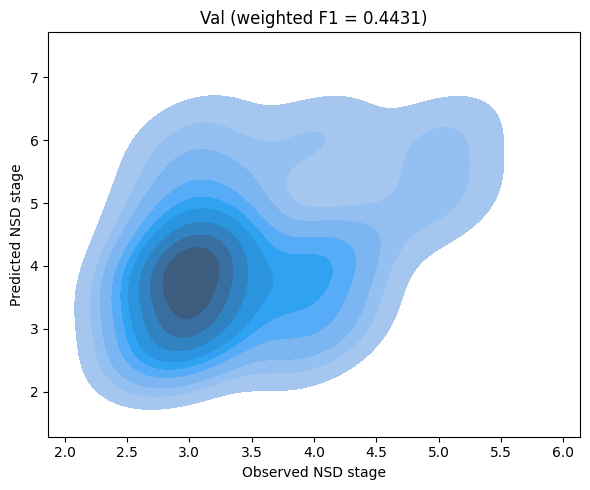

Weighted F1 (val): 0.4431


In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

f1_val = f1_score(
    true_cat_val,
    pred_cat_val,
    average="weighted",
    labels=full_cats.astype(float),
    zero_division=0,
)

plt.figure(figsize=(6, 5))
sns.kdeplot(x=true_cat_val, y=pred_cat_val, fill=True)
plt.xlabel("Observed NSD stage")
plt.ylabel("Predicted NSD stage")
plt.title(f"Val (weighted F1 = {f1_val:.4f})")
plt.tight_layout()
plt.show()
print(f"Weighted F1 (val): {f1_val:.4f}")

### ignore everything down here

In [126]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import kendalltau

def make_subject_features(df):
    records = []
    for subj, grp in df.groupby("subj_id"):
        grp = grp.sort_values("time")

        beta = grp["beta_best"].iloc[-1]
        subtype = grp["subtype_best"].iloc[-1]

        mca_last = grp["MCATOT"].iloc[-1]
        td_last = grp["TD_score"].iloc[-1]
        pigd_last = grp["PIGD_score"].iloc[-1]
        nhy_last = grp["NHY"].iloc[-1]

        n_visits = len(grp)
        if n_visits >= 2:
            t = grp["time"].values
            mca_slope = np.polyfit(t, grp["MCATOT"].values, 1)[0]
            td_slope = np.polyfit(t, grp["TD_score"].values, 1)[0]
            pigd_slope = np.polyfit(t, grp["PIGD_score"].values, 1)[0]
        else:
            mca_slope = td_slope = pigd_slope = np.nan

        nsd = grp["NSD_STAGE"].dropna()
        nsd_label = nsd.iloc[-1] if len(nsd) > 0 else np.nan

        records.append(
            {
                "subj_id": subj,
                "beta": beta,
                "subtype": subtype,
                "mca_last": mca_last,
                "td_last": td_last,
                "pigd_last": pigd_last,
                "nhy_last": nhy_last,
                "mca_slope": mca_slope,
                "td_slope": td_slope,
                "pigd_slope": pigd_slope,
                "n_visits": n_visits,
                "split": grp["model_split_best"].iloc[0],
                "NSD_label": nsd_label,
            }
        )
    return pd.DataFrame(records)


def canonical_nsd_label(x):
    """Not NSD / missing -> NaN; 2b -> 2; numeric strings -> float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ("not nsd",):
        return np.nan
    if s.lower() == "2b":
        return 2.0
    v = pd.to_numeric(s, errors="coerce")
    return float(v) if np.isfinite(v) else np.nan


data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols.csv"
df_all = pd.read_csv(data_path)

subj_df = make_subject_features(df_all)

# subtype dummies (no imaging PCs)
subtype_dummies = pd.get_dummies(subj_df["subtype"], prefix="subtype", drop_first=True)
subj_df = pd.concat([subj_df, subtype_dummies], axis=1)

FEATURES = [
    "beta",
    "mca_last",
    "td_last",
    "pigd_last",
    "nhy_last",
    "mca_slope",
    "td_slope",
    "pigd_slope",
] + list(subtype_dummies.columns)

ord_train = subj_df[(subj_df["split"] == "train") & subj_df["NSD_label"].notna()].copy()
ord_val = subj_df[(subj_df["split"] == "val") & subj_df["NSD_label"].notna()].copy()

for c in ["mca_slope", "td_slope", "pigd_slope"]:
    ord_train[c] = ord_train[c].fillna(0.0)
    ord_val[c] = ord_val[c].fillna(0.0)

ord_train["NSD_num"] = ord_train["NSD_label"].map(canonical_nsd_label)
ord_val["NSD_num"] = ord_val["NSD_label"].map(canonical_nsd_label)

# Ordinal target for stages 3-6 (merge 5+6)
stage_map = {3.0: 3, 4.0: 4, 5.0: 5, 6.0: 5}
ord_train["NSD_3cls"] = ord_train["NSD_num"].map(stage_map)
ord_val["NSD_3cls"] = ord_val["NSD_num"].map(stage_map)

bad_train = ord_train["NSD_3cls"].isna()
if bad_train.any():
    print("Dropped TRAIN rows (no usable NSD stage for {3,4,5,6} model):", int(bad_train.sum()))
    print(ord_train.loc[bad_train, "NSD_label"].value_counts(dropna=False))
ord_train = ord_train.loc[~bad_train].copy()

bad_val = ord_val["NSD_3cls"].isna()
if bad_val.any():
    print("Dropped VAL rows (no usable NSD stage for {3,4,5,6} model):", int(bad_val.sum()))
    print(ord_val.loc[bad_val, "NSD_label"].value_counts(dropna=False))
ord_val = ord_val.loc[~bad_val].copy()

cats = [3, 4, 5]
y_train = pd.Categorical(ord_train["NSD_3cls"], categories=cats, ordered=True)
y_val = pd.Categorical(ord_val["NSD_3cls"], categories=cats, ordered=True)

X_train = ord_train[FEATURES].astype(float).copy()
X_val = ord_val[FEATURES].astype(float).copy()

# Standardize continuous columns only; keep subtype dummies as 0/1
cont_feats = [f for f in FEATURES if not str(f).startswith("subtype_")]
feat_scaler = StandardScaler()
X_train.loc[:, cont_feats] = feat_scaler.fit_transform(X_train[cont_feats])
X_val.loc[:, cont_feats] = feat_scaler.transform(X_val[cont_feats])

# Balanced weights
y_train_int = ord_train["NSD_3cls"].astype(int).to_numpy()
w_train = compute_sample_weight("balanced", y=y_train_int)

print("\nTrain class counts (NSD_3cls):")
print(ord_train["NSD_3cls"].value_counts().sort_index())
print("\nVal class counts (NSD_3cls):")
print(ord_val["NSD_3cls"].value_counts().sort_index())
print(f"\nFinal sizes: train={len(ord_train)} val={len(ord_val)}")
print("Features:", FEATURES)

# ─────────────────────────────────────────────────────────────────────────────
# 3) Fit and evaluate
# ─────────────────────────────────────────────────────────────────────────────
mod = WeightedOrderedModel(y_train, X_train, sample_weights=w_train, distr="logit")
res = mod.fit(method="bfgs", disp=False, cov_type="HC1")
print(res.summary())


def evaluate(res, X, y_true, label=""):
    probs = res.model.predict(res.params, exog=X)
    pred_idx = np.argmax(probs, axis=1)
    cats_local = list(y_true.categories)

    idx = X.index
    pred_cat = pd.Series([cats_local[i] for i in pred_idx], index=idx).astype(float)
    true_cat = pd.Series(np.asarray(y_true), index=idx).astype(float)

    acc = float((pred_cat == true_cat).mean())
    within1 = float((np.abs(pred_cat.values - true_cat.values) <= 1).mean())
    tau, p = kendalltau(true_cat, pred_cat)

    print(f"\n{label}  acc={acc:.3f}  within-1={within1:.3f}  tau={tau:.3f} (p={p:.3f})")
    return pred_cat

_ = evaluate(res, X_train, y_train, "TRAIN")
_ = evaluate(res, X_val, y_val, "VAL  ")

Dropped TRAIN rows (no usable NSD stage for {3,4,5,6} model): 14
NSD_label
Not NSD    7
2b         7
Name: count, dtype: int64
Dropped VAL rows (no usable NSD stage for {3,4,5,6} model): 4
NSD_label
2b         3
Not NSD    1
Name: count, dtype: int64

Train class counts (NSD_3cls):
NSD_3cls
3.0    67
4.0    28
5.0     3
Name: count, dtype: int64

Val class counts (NSD_3cls):
NSD_3cls
3.0    17
4.0     6
5.0     2
Name: count, dtype: int64

Final sizes: train=98 val=25
Features: ['beta', 'mca_last', 'td_last', 'pigd_last', 'nhy_last', 'mca_slope', 'td_slope', 'pigd_slope', 'subtype_1.0', 'subtype_2.0']
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:                -56.581
Model:             WeightedOrderedModel   AIC:                             137.2
Method:              Maximum Likelihood   BIC:                             168.2
Date:                  Mon, 27 Apr 2026                            

In [127]:
# Standalone cell compatible with current NSD_predict notebook state
# Assumes: ord_train, ord_val, WeightedOrderedModel, and evaluate are already defined in earlier cells.

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report
from scipy.stats import kendalltau, spearmanr

# Safety checks
required_cols = {"NSD_3cls", "beta", "pigd_last", "nhy_last"}
for nm, d in [("ord_train", ord_train), ("ord_val", ord_val)]:
    missing = required_cols - set(d.columns)
    if missing:
        raise ValueError(f"{nm} missing columns: {sorted(missing)}")

# ── Option A: Collapse to binary ──────────────────────────────────────────────
ord_train = ord_train.copy()
ord_val = ord_val.copy()

ord_train["NSD_bin"] = (ord_train["NSD_3cls"] >= 4).astype(int)
ord_val["NSD_bin"] = (ord_val["NSD_3cls"] >= 4).astype(int)

print("Train binary:", ord_train["NSD_bin"].value_counts().sort_index().to_dict())
print("Val binary:", ord_val["NSD_bin"].value_counts().sort_index().to_dict())

# ── Option B: Lean ordinal model (3 features) ─────────────────────────────────
FEATURES_LEAN = ["beta", "pigd_last", "nhy_last"]

# Fill any missing predictors (if present)
for c in FEATURES_LEAN:
    ord_train[c] = pd.to_numeric(ord_train[c], errors="coerce")
    ord_val[c] = pd.to_numeric(ord_val[c], errors="coerce")
ord_train[FEATURES_LEAN] = ord_train[FEATURES_LEAN].fillna(0.0)
ord_val[FEATURES_LEAN] = ord_val[FEATURES_LEAN].fillna(0.0)

# ──────────────────────────────────────────────────────────────────────────────
# Fit A: Binary logistic
# ──────────────────────────────────────────────────────────────────────────────
feat_scaler_bin = StandardScaler()
X_tr_bin = feat_scaler_bin.fit_transform(ord_train[FEATURES_LEAN])
X_va_bin = feat_scaler_bin.transform(ord_val[FEATURES_LEAN])

clf = LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    clf,
    {"C": [0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=cv,
    scoring="balanced_accuracy",
    refit=True,
)
gs.fit(X_tr_bin, ord_train["NSD_bin"])

print(f"\nBest C: {gs.best_params_['C']:.3f}")
print(f"CV balanced acc: {gs.best_score_:.3f}")

best_clf = gs.best_estimator_
val_pred_bin = best_clf.predict(X_va_bin)
val_prob_bin = best_clf.predict_proba(X_va_bin)[:, 1]

print(f"\nVal balanced acc: {balanced_accuracy_score(ord_val['NSD_bin'], val_pred_bin):.3f}")
print(f"Val ROC-AUC:      {roc_auc_score(ord_val['NSD_bin'], val_prob_bin):.3f}")
print(
    "\n",
    classification_report(
        ord_val["NSD_bin"], val_pred_bin, target_names=["Stage3", "Stage4+"]
    ),
)

tau, p = kendalltau(ord_val["NSD_3cls"], val_prob_bin)
print(f"Val Kendall tau (prob vs ordinal NSD): tau={tau:.3f} p={p:.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# Fit B: Lean weighted ordinal model
# ──────────────────────────────────────────────────────────────────────────────
feat_scaler_ord = StandardScaler()
X_tr_ord = pd.DataFrame(
    feat_scaler_ord.fit_transform(ord_train[FEATURES_LEAN]),
    columns=FEATURES_LEAN,
    index=ord_train.index,
)
X_va_ord = pd.DataFrame(
    feat_scaler_ord.transform(ord_val[FEATURES_LEAN]),
    columns=FEATURES_LEAN,
    index=ord_val.index,
)

cats = [3, 4, 5]
y_tr_ord = pd.Categorical(ord_train["NSD_3cls"], categories=cats, ordered=True)
y_va_ord = pd.Categorical(ord_val["NSD_3cls"], categories=cats, ordered=True)

# compute_sample_weight expects plain labels, not Categorical
w_tr = compute_sample_weight("balanced", y=ord_train["NSD_3cls"].astype(int).to_numpy())

mod_lean = WeightedOrderedModel(y_tr_ord, X_tr_ord, sample_weights=w_tr, distr="logit")
res_lean = mod_lean.fit(method="bfgs", disp=False, cov_type="HC1")
print(res_lean.summary())

_ = evaluate(res_lean, X_tr_ord, y_tr_ord, "LEAN TRAIN")
_ = evaluate(res_lean, X_va_ord, y_va_ord, "LEAN VAL  ")

# ──────────────────────────────────────────────────────────────────────────────
# Sanity checks
# ──────────────────────────────────────────────────────────────────────────────
rho, p_rho = spearmanr(ord_val["beta"], ord_val["NSD_3cls"])
print(f"\nbeta vs NSD (val) Spearman rho={rho:.3f} p={p_rho:.3f}")

rho2, p2 = spearmanr(ord_val["nhy_last"], ord_val["NSD_3cls"])
print(f"NHY  vs NSD (val) Spearman rho={rho2:.3f} p={p2:.3f}")

rho3, p3 = spearmanr(ord_val["pigd_last"], ord_val["NSD_3cls"])
print(f"PIGD vs NSD (val) Spearman rho={rho3:.3f} p={p3:.3f}")

Train binary: {0: 67, 1: 31}
Val binary: {0: 17, 1: 8}

Best C: 0.500
CV balanced acc: 0.684

Val balanced acc: 0.636
Val ROC-AUC:      0.706

               precision    recall  f1-score   support

      Stage3       0.79      0.65      0.71        17
     Stage4+       0.45      0.62      0.53         8

    accuracy                           0.64        25
   macro avg       0.62      0.64      0.62        25
weighted avg       0.68      0.64      0.65        25

Val Kendall tau (prob vs ordinal NSD): tau=0.266 p=0.108
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:                -98.738
Model:             WeightedOrderedModel   AIC:                             207.5
Method:              Maximum Likelihood   BIC:                             220.4
Date:                  Mon, 27 Apr 2026                                         
Time:                          18:56:55                            

=== Raw subtype signal ===

Val contingency (subtype vs NSD_3cls):
NSD_3cls  3.0  4.0  5.0
subtype                
0.0        15    5    2
1.0         1    1    0
2.0         1    0    0
Chi2=1.34, p=0.855, dof=4

Val contingency (subtype vs NSD_bin):
NSD_bin   0  1
subtype       
0.0      15  7
1.0       1  1
2.0       1  0
Chi2=0.77, p=0.681, dof=2

Kruskal-Wallis NSD_3cls across subtypes: H=0.61, p=0.738

Train contingency:
NSD_3cls  3.0  4.0  5.0
subtype                
0.0        31   13    1
1.0        27   10    0
2.0         9    5    2
Chi2=6.43, p=0.170

=== Model comparison with subtype ===
Model                         AUC    bal_acc   τ (val)
------------------------------------------------------------
NHY                           0.695  0.614     τ=0.379 (p=0.049)
NHY + PIGD                    0.721  0.636     τ=0.300 (p=0.084)
NHY + beta                    0.676  0.724     τ=0.275 (p=0.096)
NHY + subtype                 0.713  0.625     τ=0.368 (p=0.048)
NHY + PIGD + su

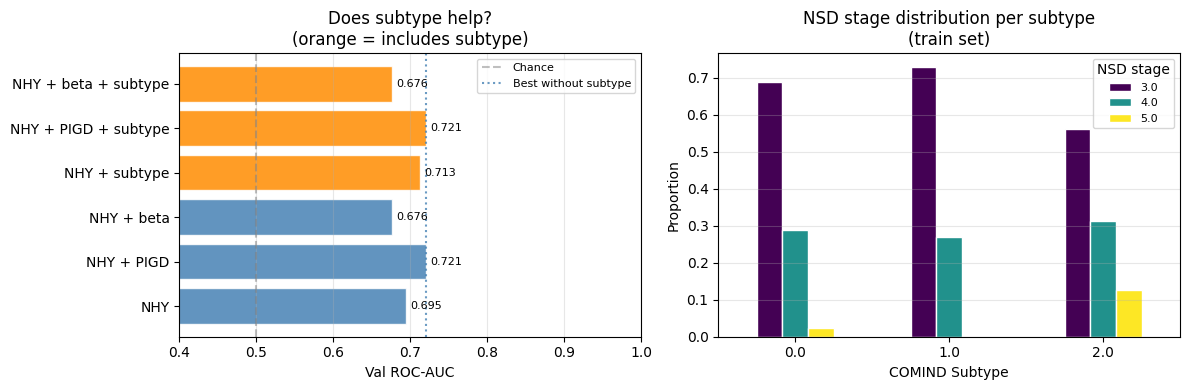

In [128]:
# ── Does subtype add anything beyond NHY? (self-contained) ───────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, chi2_contingency, kendalltau
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# Requires ord_train, ord_val with columns:
# subtype, NSD_3cls, NSD_bin, nhy_last, pigd_last, beta

# First: raw association
print("=== Raw subtype signal ===")
for col in ["NSD_3cls", "NSD_bin"]:
    ct = pd.crosstab(ord_val["subtype"], ord_val[col])
    print(f"\nVal contingency (subtype vs {col}):\n{ct}")
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"Chi2={chi2:.2f}, p={p:.3f}, dof={dof}")

groups = [ord_val.loc[ord_val["subtype"] == s, "NSD_3cls"].dropna()
          for s in sorted(ord_val["subtype"].dropna().unique())]
if len(groups) >= 2 and all(len(g) > 0 for g in groups):
    h, p_kw = kruskal(*groups)
    print(f"\nKruskal-Wallis NSD_3cls across subtypes: H={h:.2f}, p={p_kw:.3f}")
else:
    print("\nKruskal-Wallis skipped (not enough non-empty subtype groups).")

ct_train = pd.crosstab(ord_train["subtype"], ord_train["NSD_3cls"])
print(f"\nTrain contingency:\n{ct_train}")
chi2_tr, p_tr, _, _ = chi2_contingency(ct_train)
print(f"Chi2={chi2_tr:.2f}, p={p_tr:.3f}")

# Build subtype dummies and align train/val
subtype_dummies_tr = pd.get_dummies(ord_train["subtype"], prefix="subtype", drop_first=True)
subtype_dummies_val = pd.get_dummies(ord_val["subtype"], prefix="subtype", drop_first=True)
subtype_dummies_tr, subtype_dummies_val = subtype_dummies_tr.align(
    subtype_dummies_val, join="outer", axis=1, fill_value=0
)
subtype_cols = list(subtype_dummies_tr.columns)

ord_train_s = pd.concat(
    [ord_train.reset_index(drop=True), subtype_dummies_tr.reset_index(drop=True)], axis=1
)
ord_val_s = pd.concat(
    [ord_val.reset_index(drop=True), subtype_dummies_val.reset_index(drop=True)], axis=1
)

# Define baseline + subtype model specs here (no external `results` needed)
model_specs = {
    "NHY": ["nhy_last"],
    "NHY + PIGD": ["nhy_last", "pigd_last"],
    "NHY + beta": ["nhy_last", "beta"],
    "NHY + subtype": ["nhy_last"] + subtype_cols,
    "NHY + PIGD + subtype": ["nhy_last", "pigd_last"] + subtype_cols,
    "NHY + beta + subtype": ["nhy_last", "beta"] + subtype_cols,
}

print("\n=== Model comparison with subtype ===")
print(f"{'Model':<28}  AUC    bal_acc   τ (val)")
print("-" * 60)

roc_data = {}
for name, feats in model_specs.items():
    cont = [f for f in feats if not str(f).startswith("subtype_")]
    dum = [f for f in feats if str(f).startswith("subtype_")]

    Xtr = ord_train_s[cont].copy()
    Xva = ord_val_s[cont].copy()

    sc = StandardScaler()
    Xtr[cont] = sc.fit_transform(Xtr[cont])
    Xva[cont] = sc.transform(Xva[cont])

    if dum:
        Xtr = pd.concat([Xtr, ord_train_s[dum].reset_index(drop=True)], axis=1)
        Xva = pd.concat([Xva, ord_val_s[dum].reset_index(drop=True)], axis=1)

    clf = LogisticRegression(class_weight="balanced", C=0.5, solver="lbfgs", max_iter=1000)
    clf.fit(Xtr, ord_train_s["NSD_bin"])

    prob_va = clf.predict_proba(Xva)[:, 1]
    pred_va = clf.predict(Xva)

    tau, tau_p = kendalltau(ord_val_s["NSD_3cls"], prob_va)
    r = {
        "auc": roc_auc_score(ord_val_s["NSD_bin"], prob_va),
        "bacc": balanced_accuracy_score(ord_val_s["NSD_bin"], pred_va),
        "tau": tau,
        "tau_p": tau_p,
        "prob": prob_va,
    }
    roc_data[name] = r

    print(f"{name:<28}  {r['auc']:.3f}  {r['bacc']:.3f}     τ={r['tau']:.3f} (p={r['tau_p']:.3f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: AUC bars
ax = axes[0]
names = list(roc_data.keys())
aucs = [roc_data[n]["auc"] for n in names]
colors = ["steelblue" if "subtype" not in n else "darkorange" for n in names]
bars = ax.barh(names, aucs, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")

best_no_subtype_auc = max(v["auc"] for k, v in roc_data.items() if "subtype" not in k)
ax.axvline(best_no_subtype_auc, color="steelblue", linestyle=":", alpha=0.8, label="Best without subtype")

ax.set_xlabel("Val ROC-AUC")
ax.set_title("Does subtype help?\n(orange = includes subtype)")
ax.set_xlim(0.4, 1.0)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
for bar, auc in zip(bars, aucs):
    ax.text(auc + 0.005, bar.get_y() + bar.get_height()/2, f"{auc:.3f}", va="center", fontsize=8)

# Panel 2: train subtype vs stage distribution
ax = axes[1]
ct_pct = ct_train.div(ct_train.sum(axis=1), axis=0)
ct_pct.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="white")
ax.set_xlabel("COMIND Subtype")
ax.set_ylabel("Proportion")
ax.set_title("NSD stage distribution per subtype\n(train set)")
ax.legend(title="NSD stage", fontsize=8)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("subtype_nsd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Model                     CV-AUC±SD    Val-AUC   Val-bAcc  Val-τ (p)
──────────────────────────────────────────────────────────────────────────
Tree (depth=2)            0.682±0.147    0.732     0.665     τ=0.371 (p=0.05) ◄
Tree (depth=3)            0.638±0.105    0.746     0.665     τ=0.351 (p=0.05) ◄
Random Forest             0.660±0.103    0.721     0.665     τ=0.312 (p=0.07) ◄
GBM                       0.653±0.121    0.713     0.721     τ=0.280 (p=0.11)
SVM (RBF)                 0.650±0.166    0.691     0.721     τ=0.249 (p=0.15)
SVM (linear)              0.655±0.136    0.684     0.636     τ=0.249 (p=0.15)
KNN (k=3)                 0.573±0.039    0.621     0.688     τ=0.196 (p=0.30)
KNN (k=5)                 0.649±0.085    0.673     0.688     τ=0.246 (p=0.17)
Naive Bayes               0.664±0.117    0.706     0.688     τ=0.270 (p=0.12)
Logistic (baseline)       0.667±0.141    0.721     0.636     τ=0.300 (p=0.08) ◄


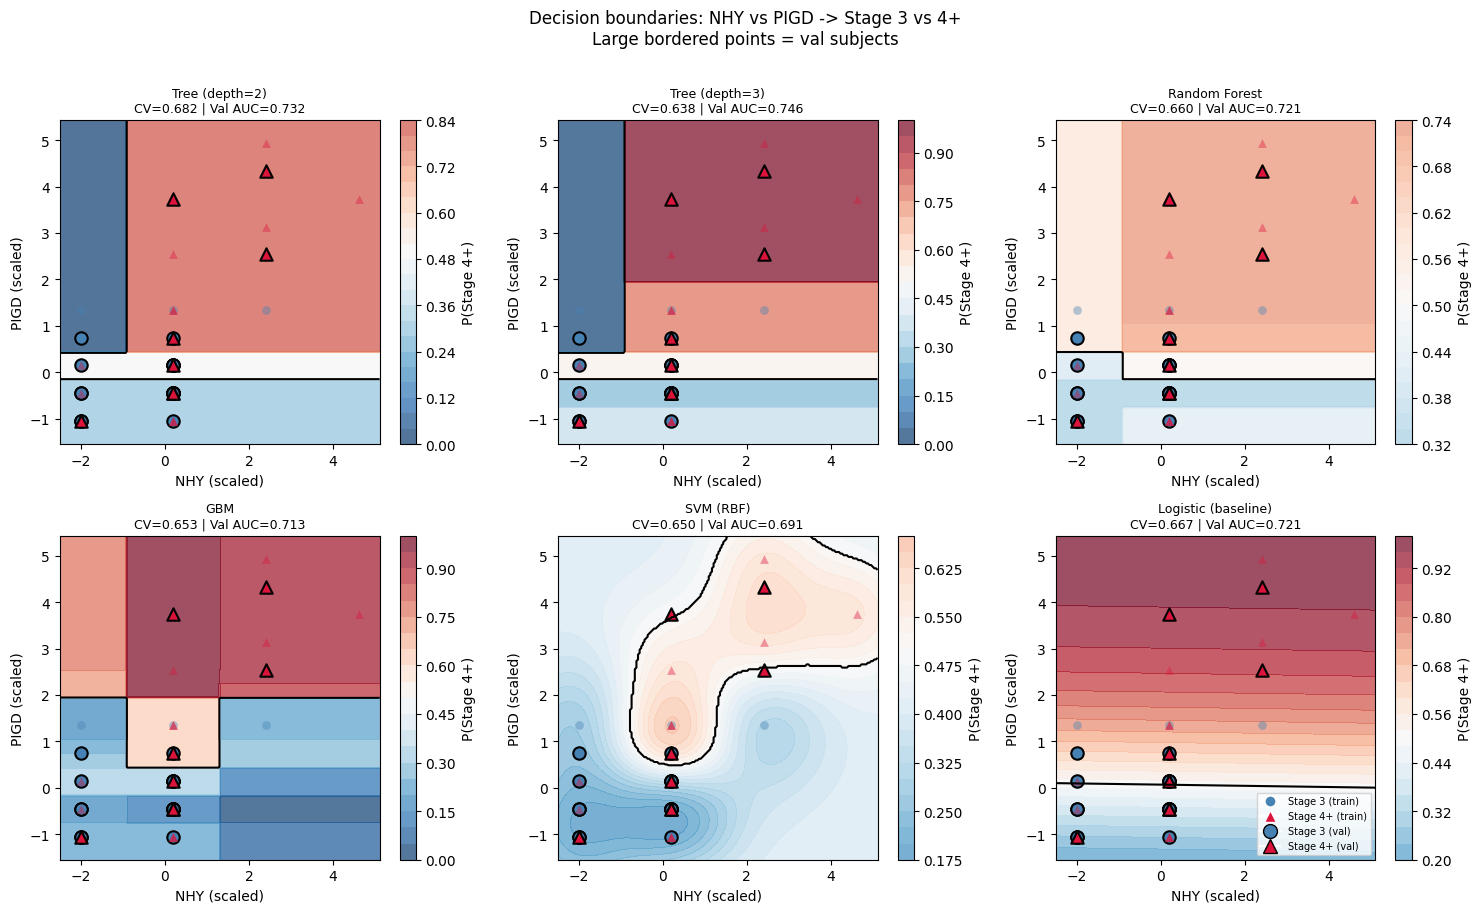


=== Depth-2 tree as explicit rule ===
|--- pigd_last (scaled) <= 0.45
|   |--- pigd_last (scaled) <= -0.15
|   |   |--- class: 0
|   |--- pigd_last (scaled) >  -0.15
|   |   |--- class: 1
|--- pigd_last (scaled) >  0.45
|   |--- nhy_last (scaled) <= -0.90
|   |   |--- class: 0
|   |--- nhy_last (scaled) >  -0.90
|   |   |--- class: 1


Thresholds in original units:
  Node 0: pigd_last <= 2.50
  Node 1: pigd_last <= 1.50
  Node 4: nhy_last <= 1.50


In [129]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import kendalltau

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Compatibility guards
# ---------------------------------------------------------------------
ord_train = ord_train.copy()
ord_val = ord_val.copy()

# If NSD_bin not already created, derive it from NSD_3cls
if "NSD_bin" not in ord_train.columns:
    ord_train["NSD_bin"] = (ord_train["NSD_3cls"] >= 4).astype(int)
if "NSD_bin" not in ord_val.columns:
    ord_val["NSD_bin"] = (ord_val["NSD_3cls"] >= 4).astype(int)

FEATURES = ["nhy_last", "pigd_last"]  # established best pair

# Keep only complete rows for required columns
need_cols = FEATURES + ["NSD_bin", "NSD_3cls"]
ord_train_m = ord_train.dropna(subset=need_cols).copy()
ord_val_m = ord_val.dropna(subset=need_cols).copy()

y_tr = ord_train_m["NSD_bin"].astype(int).values
y_va = ord_val_m["NSD_bin"].astype(int).values
X_tr = ord_train_m[FEATURES].astype(float).values
X_va = ord_val_m[FEATURES].astype(float).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------------
# Candidate models (all constrained for small N)
# ---------------------------------------------------------------------
candidates = {
    "Tree (depth=2)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42))
    ]),
    "Tree (depth=3)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("sc", StandardScaler()),
        ("m",  RandomForestClassifier(
            n_estimators=200, max_depth=3, min_samples_leaf=5,
            class_weight="balanced", random_state=42
        ))
    ]),
    "GBM": Pipeline([
        ("sc", StandardScaler()),
        ("m",  GradientBoostingClassifier(
            n_estimators=100, max_depth=2, learning_rate=0.05,
            subsample=0.8, random_state=42
        ))
    ]),
    "SVM (RBF)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  SVC(kernel="rbf", C=1.0, gamma="scale",
                   class_weight="balanced", probability=True, random_state=42))
    ]),
    "SVM (linear)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  SVC(kernel="linear", C=0.5,
                   class_weight="balanced", probability=True, random_state=42))
    ]),
    "KNN (k=3)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  KNeighborsClassifier(n_neighbors=3, weights="distance"))
    ]),
    "KNN (k=5)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  KNeighborsClassifier(n_neighbors=5, weights="distance"))
    ]),
    "Naive Bayes": Pipeline([
        ("sc", StandardScaler()),
        ("m",  GaussianNB())
    ]),
    "Logistic (baseline)": Pipeline([
        ("sc", StandardScaler()),
        ("m",  LogisticRegression(
            C=0.5, class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=42
        ))
    ]),
}

# ---------------------------------------------------------------------
# Evaluate all candidates
# ---------------------------------------------------------------------
print(f"{'Model':<24}  CV-AUC±SD    Val-AUC   Val-bAcc  Val-τ (p)")
print("─" * 74)

all_results = {}
for name, pipe in candidates.items():
    cv_aucs = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc")
    pipe.fit(X_tr, y_tr)

    prob_va = pipe.predict_proba(X_va)[:, 1]
    pred_va = pipe.predict(X_va)

    val_auc = roc_auc_score(y_va, prob_va)
    val_bacc = balanced_accuracy_score(y_va, pred_va)
    tau, p = kendalltau(ord_val_m["NSD_3cls"].astype(float).values, prob_va)

    all_results[name] = {
        "cv_mean": cv_aucs.mean(),
        "cv_std": cv_aucs.std(),
        "val_auc": val_auc,
        "val_bacc": val_bacc,
        "tau": tau,
        "tau_p": p,
        "pipe": pipe,
        "prob": prob_va,
    }

    flag = " ◄" if val_auc > 0.72 else ""
    print(f"{name:<24}  {cv_aucs.mean():.3f}±{cv_aucs.std():.3f}    "
          f"{val_auc:.3f}     {val_bacc:.3f}     τ={tau:.3f} (p={p:.2f}){flag}")

# ---------------------------------------------------------------------
# Decision-boundary plots
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Shared plotting scale
sc_plot = StandardScaler().fit(X_tr)
X_tr_s = sc_plot.transform(X_tr)
X_va_s = sc_plot.transform(X_va)

x_min, x_max = X_tr_s[:, 0].min() - 0.5, X_tr_s[:, 0].max() + 0.5
y_min, y_max = X_tr_s[:, 1].min() - 0.5, X_tr_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

plot_models = [
    "Tree (depth=2)", "Tree (depth=3)", "Random Forest",
    "GBM", "SVM (RBF)", "Logistic (baseline)"
]

for ax, mname in zip(axes.flat, plot_models):
    pipe_plot = candidates[mname]
    pipe_plot.fit(X_tr, y_tr)

    # Create grid in ORIGINAL units so pipeline scaler handles transforms consistently
    grid_orig = sc_plot.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
    Z = pipe_plot.predict_proba(grid_orig)[:, 1].reshape(xx.shape)

    cf = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.7, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)
    plt.colorbar(cf, ax=ax, label="P(Stage 4+)")

    for stage, marker, size in [(0, "o", 40), (1, "^", 40)]:
        m_tr = y_tr == stage
        m_va = y_va == stage
        ax.scatter(X_tr_s[m_tr, 0], X_tr_s[m_tr, 1],
                   c="steelblue" if stage == 0 else "crimson",
                   marker=marker, s=size, alpha=0.4, linewidths=0)
        ax.scatter(X_va_s[m_va, 0], X_va_s[m_va, 1],
                   c="steelblue" if stage == 0 else "crimson",
                   marker=marker, s=size * 2, alpha=1.0,
                   edgecolors="black", linewidths=1.5)

    r = all_results[mname]
    ax.set_title(f"{mname}\nCV={r['cv_mean']:.3f} | Val AUC={r['val_auc']:.3f}", fontsize=9)
    ax.set_xlabel("NHY (scaled)")
    ax.set_ylabel("PIGD (scaled)")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=8, label="Stage 3 (train)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="crimson",
           markersize=8, label="Stage 4+ (train)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=10, markeredgecolor="black", label="Stage 3 (val)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="crimson",
           markersize=10, markeredgecolor="black", label="Stage 4+ (val)"),
]
axes.flat[-1].legend(handles=legend_elements, fontsize=7, loc="lower right")

plt.suptitle("Decision boundaries: NHY vs PIGD -> Stage 3 vs 4+\nLarge bordered points = val subjects", y=1.01)
plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------
# Explicit depth-2 decision rule
# ---------------------------------------------------------------------
print("\n=== Depth-2 tree as explicit rule ===")
best_tree_pipe = all_results["Tree (depth=2)"]["pipe"]
dt2 = best_tree_pipe.named_steps["m"]
sc2 = best_tree_pipe.named_steps["sc"]

print(export_text(dt2, feature_names=[f"{f} (scaled)" for f in FEATURES]))

print("\nThresholds in original units:")
for i, threshold in enumerate(dt2.tree_.threshold):
    if threshold != -2:  # -2 means leaf node
        feat_idx = dt2.tree_.feature[i]
        feat_name = FEATURES[feat_idx]
        original = threshold * sc2.scale_[feat_idx] + sc2.mean_[feat_idx]
        print(f"  Node {i}: {feat_name} <= {original:.2f}")